In [1]:
import os
os.chdir('../../../..')

In [2]:
import polars as pl
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from umap import UMAP

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, pairwise_distances

from src.datasets import QM9Dataset

In [3]:
qm9 = QM9Dataset(limit=2_500, descriptors=["chemprop", "transformer", "morgan", "onehot"])
df = qm9.load()

2026-06-11 09:43:20.479 | INFO     | src.datasets:_load_full_qm9_df:934 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-06-11 09:43:21.123 | INFO     | src.datasets:_sample_qm9_df:1118 - QM9 sampling complete: strategy=stratified, requested_limit=2500, returned_rows=2500, sampling on columns=['num_atoms', 'gap'].
2026-06-11 09:43:21.125 | INFO     | src.datasets:_add_requested_descriptors:292 - Applying requested QM9 descriptors to sampled dataframe (rows=2500).
2026-06-11 09:43:21.125 | INFO     | src.features:compute_chemprop_embeddings:710 - Computing Chemprop embeddings on mps...
2026-06-11 09:43:21.126 | INFO     | scripts.qm9.chemprop:__init__:28 - Initializing CheMeleonFingerprint generator...
2026-06-11 09:43:21.127 | INFO     | scripts.qm9.chemprop:__init__:48 - Found existing CheMeleon weights at /Users/karlfindhansen/.chemprop/chemeleon_mp.pt
2026-06-11 09:43:21.200 | SUCCESS  | scripts.qm9.chemprop:__init__:54 - Successfully loaded CheMeleon me

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

2026-06-11 09:44:04.385 | INFO     | src.features:compute_morgan_fingerprints:225 - Computing Morgan Fingerprints (Radius=2, Size=2048)...
2026-06-11 09:44:12.457 | INFO     | src.features:compute_selfies_onehot:284 - Computing One-Hot Encodings...
2026-06-11 09:44:12.704 | INFO     | src.datasets:_add_requested_descriptors:303 - Added descriptor column(s): ['chemprop_embedding', 'morgan_fingerprint', 'selfies_onehot', 'selfies_transformer']


# Compare how all of the methods compare to each other and how they predict different features respectively.

In [4]:
classes = ["Acyclic", "Aliphatic Ring", "Aromatic"]
df_exp = pl.concat([
    df.filter(pl.col("structure_class") == cls).sample(n=100, seed=42)
    for cls in classes
])

true_labels = df_exp["structure_class"].to_numpy()
n_classes = len(np.unique(true_labels))

In [5]:
# 1. Stratified Data Sampling
classes = ["Acyclic", "Aliphatic Ring", "Aromatic"]
df_exp = pl.concat([
    df.filter(pl.col("structure_class") == cls).sample(n=100, seed=42)
    for cls in classes
])

true_labels = df_exp["structure_class"].to_numpy()
n_classes = len(np.unique(true_labels))
embedding_cols = ['chemprop_embedding', 'morgan_fingerprint', 'selfies_transformer', 'selfies_onehot']
results = []

for col in embedding_cols:
    X = np.vstack(df_exp[col].to_numpy())
    
    # Define appropriate high-dimensional metric baseline
    if col == 'morgan_fingerprint' or col == 'onehot':
        X = X.astype(bool)
        raw_metric = "jaccard"
        umap_metric = "jaccard"
        # Raw clustering configuration
        hc_raw = AgglomerativeClustering(n_clusters=n_classes, metric='precomputed', linkage='complete')
        dist_matrix = pairwise_distances(X, metric=raw_metric)
        raw_preds = hc_raw.fit_predict(dist_matrix)
        sil_raw = silhouette_score(dist_matrix, raw_preds, metric='precomputed')
    else:
        raw_metric = "euclidean"
        umap_metric = "euclidean"
        # Raw clustering configuration
        hc_raw = AgglomerativeClustering(n_clusters=n_classes, metric='euclidean', linkage='ward')
        raw_preds = hc_raw.fit_predict(X)
        sil_raw = silhouette_score(X, raw_preds, metric='euclidean')
        
    ari_raw = adjusted_rand_score(true_labels, raw_preds)
    
    # 2. Apply UMAP Manifold Reduction to 2D
    reducer = UMAP(n_components=2, metric=umap_metric, n_neighbors=15, min_dist=0.1, random_state=42)
    X_umap = reducer.fit_transform(X)
    
    # 3. Agglomerative Clustering on the 2D Manifold Coordinates
    hc_umap = AgglomerativeClustering(n_clusters=n_classes, metric='euclidean', linkage='ward')
    umap_preds = hc_umap.fit_predict(X_umap)
    
    sil_umap = silhouette_score(X_umap, umap_preds, metric='euclidean')
    ari_umap = adjusted_rand_score(true_labels, umap_preds)
    
    results.append({
        "Embedding Type": col,
        "Raw Silhouette": round(sil_raw, 4),
        "Raw ARI": round(ari_raw, 4),
        "UMAP Silhouette": round(sil_umap, 4),
        "UMAP ARI": round(ari_umap, 4)
    })

df_results = pl.DataFrame(results)
print("\n=== CLUSTERING PERFORMANCE BENCHMARK ===")
print(df_results)

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarnin


=== CLUSTERING PERFORMANCE BENCHMARK ===
shape: (4, 5)
┌─────────────────────┬────────────────┬─────────┬─────────────────┬──────────┐
│ Embedding Type      ┆ Raw Silhouette ┆ Raw ARI ┆ UMAP Silhouette ┆ UMAP ARI │
│ ---                 ┆ ---            ┆ ---     ┆ ---             ┆ ---      │
│ str                 ┆ f64            ┆ f64     ┆ f64             ┆ f64      │
╞═════════════════════╪════════════════╪═════════╪═════════════════╪══════════╡
│ chemprop_embedding  ┆ 0.0894         ┆ 0.8838  ┆ 0.6199          ┆ 0.9221   │
│ morgan_fingerprint  ┆ 0.0235         ┆ 0.2733  ┆ 0.6027          ┆ 0.8289   │
│ selfies_transformer ┆ 0.0859         ┆ 0.4704  ┆ 0.4146          ┆ 0.5748   │
│ selfies_onehot      ┆ 0.0266         ┆ 0.0502  ┆ 0.3715          ┆ 0.0972   │
└─────────────────────┴────────────────┴─────────┴─────────────────┴──────────┘


In [6]:
def plot_embedding_projection(X: np.ndarray, labels: list or np.ndarray, embedding_type: str, projection_method: str = "UMAP"):
    """
    Generates a single publication-ready scatter plot from raw embeddings.
    Automatically assigns the correct distance metric based on the embedding type.
    """
    # 1. Automatically determine distance metric and optimize data types
    embedding_type_lower = embedding_type.lower()
    
    if "morgan" in embedding_type_lower:
        metric = "jaccard"
        X_input = X.astype(bool)  # Ensure proper bitmask parsing
        display_title = "2048-bit Morgan Fingerprint"
    elif "chemprop" in embedding_type_lower:
        metric = "euclidean"
        X_input = X
        display_title = "Chemprop Message-Passing"
    elif "transformer" in embedding_type_lower or "selfies" in embedding_type_lower:
        metric = "euclidean"
        X_input = X
        display_title = "SELFormer Transformer"
    else:
        metric = "euclidean"
        X_input = X
        display_title = embedding_type

    # 2. Compute Dimensionality Reduction
    if projection_method.upper() == "UMAP":
        print(f"Computing UMAP manifold reduction using '{metric}' metric...")
        reducer = UMAP(n_components=2, metric=metric, n_neighbors=15, min_dist=0.1, random_state=42)
        coords = reducer.fit_transform(X_input)
    else:
        raise ValueError(f"Unsupported projection method: {projection_method}. Only 'UMAP' is currently supported.")
    
    # 3. Prepare Data Structure for Seaborn
    plot_df = pd.DataFrame({
        "Component_1": coords[:, 0],
        "Component_2": coords[:, 1],
        "label_class": list(labels) if labels is not None else ["Unknown"] * len(coords)
    })
    
    # Force categorical cast for uniform viridis color spacing
    plot_df["label_class"] = plot_df["label_class"].astype(str).astype("category")
    n_colors = len(plot_df["label_class"].unique())

    # 4. Setup the Figure Framework and Template Style
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(11, 9), dpi=300)

    # 5. Generate Graph Plot using the Gradual Sequential Palette
    palette = sns.color_palette("viridis", n_colors=n_colors)
    
    sns.scatterplot(
        data=plot_df, 
        x="Component_1", 
        y="Component_2", 
        hue="label_class", 
        palette=palette,
        s=85,          
        alpha=0.8,     
        edgecolor='w', 
        linewidth=0.5,
        ax=ax
    )

    # 6. Typography and Layout Engineering
    ax.set_title(f"UMAP Latent Space Projection\n({display_title})", fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel(f"{projection_method} Component 1", fontsize=12, fontweight='medium')
    ax.set_ylabel(f"{projection_method} Component 2", fontsize=12, fontweight='medium')
    
    # Standardize legend position along the right frame margin
    ax.legend(
        title="Class Legend",
        bbox_to_anchor=(1.02, 1), 
        loc='upper left', 
        borderaxespad=0.,
        frameon=True,
        title_fontsize=11,
        fontsize=10
    )

    # Clean borders
    sns.despine(fig)
    plt.tight_layout()

    # Save format asset
    clean_name = display_title.lower().replace(" ", "_").replace("-", "_")
    output_filename = f"{clean_name}_{projection_method.lower()}.png"
    #plt.savefig(output_filename, bbox_inches='tight', dpi=300)
    print(f"Saved high-resolution plot to {output_filename}")
    plt.show()
    
    return fig

In [7]:
def predict_hierarchical_clusters(X: np.ndarray, n_clusters: int, embedding_type: str) -> np.ndarray:
    """
    Fits hierarchical agglomerative clustering and returns predicted labels.
    Automatically handles distance metrics and linkage types per embedding profile.
    """
    embedding_type_lower = embedding_type.lower()
    
    if "morgan" in embedding_type_lower:
        # High-dimensional binary profiles require Jaccard precomputation
        X_input = X.astype(bool)
        dist_matrix = pairwise_distances(X_input, metric="jaccard")
        
        hc = AgglomerativeClustering(n_clusters=n_clusters, metric='precomputed', linkage='complete')
        predicted_labels = hc.fit_predict(dist_matrix)
        
    else:
        # Continuous dense vectors use Euclidean distance + Ward variance minimization
        hc = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='average')
        predicted_labels = hc.fit_predict(X)
        
    return predicted_labels

Computing UMAP manifold reduction using 'jaccard' metric...


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved high-resolution plot to 2048_bit_morgan_fingerprint_umap.png


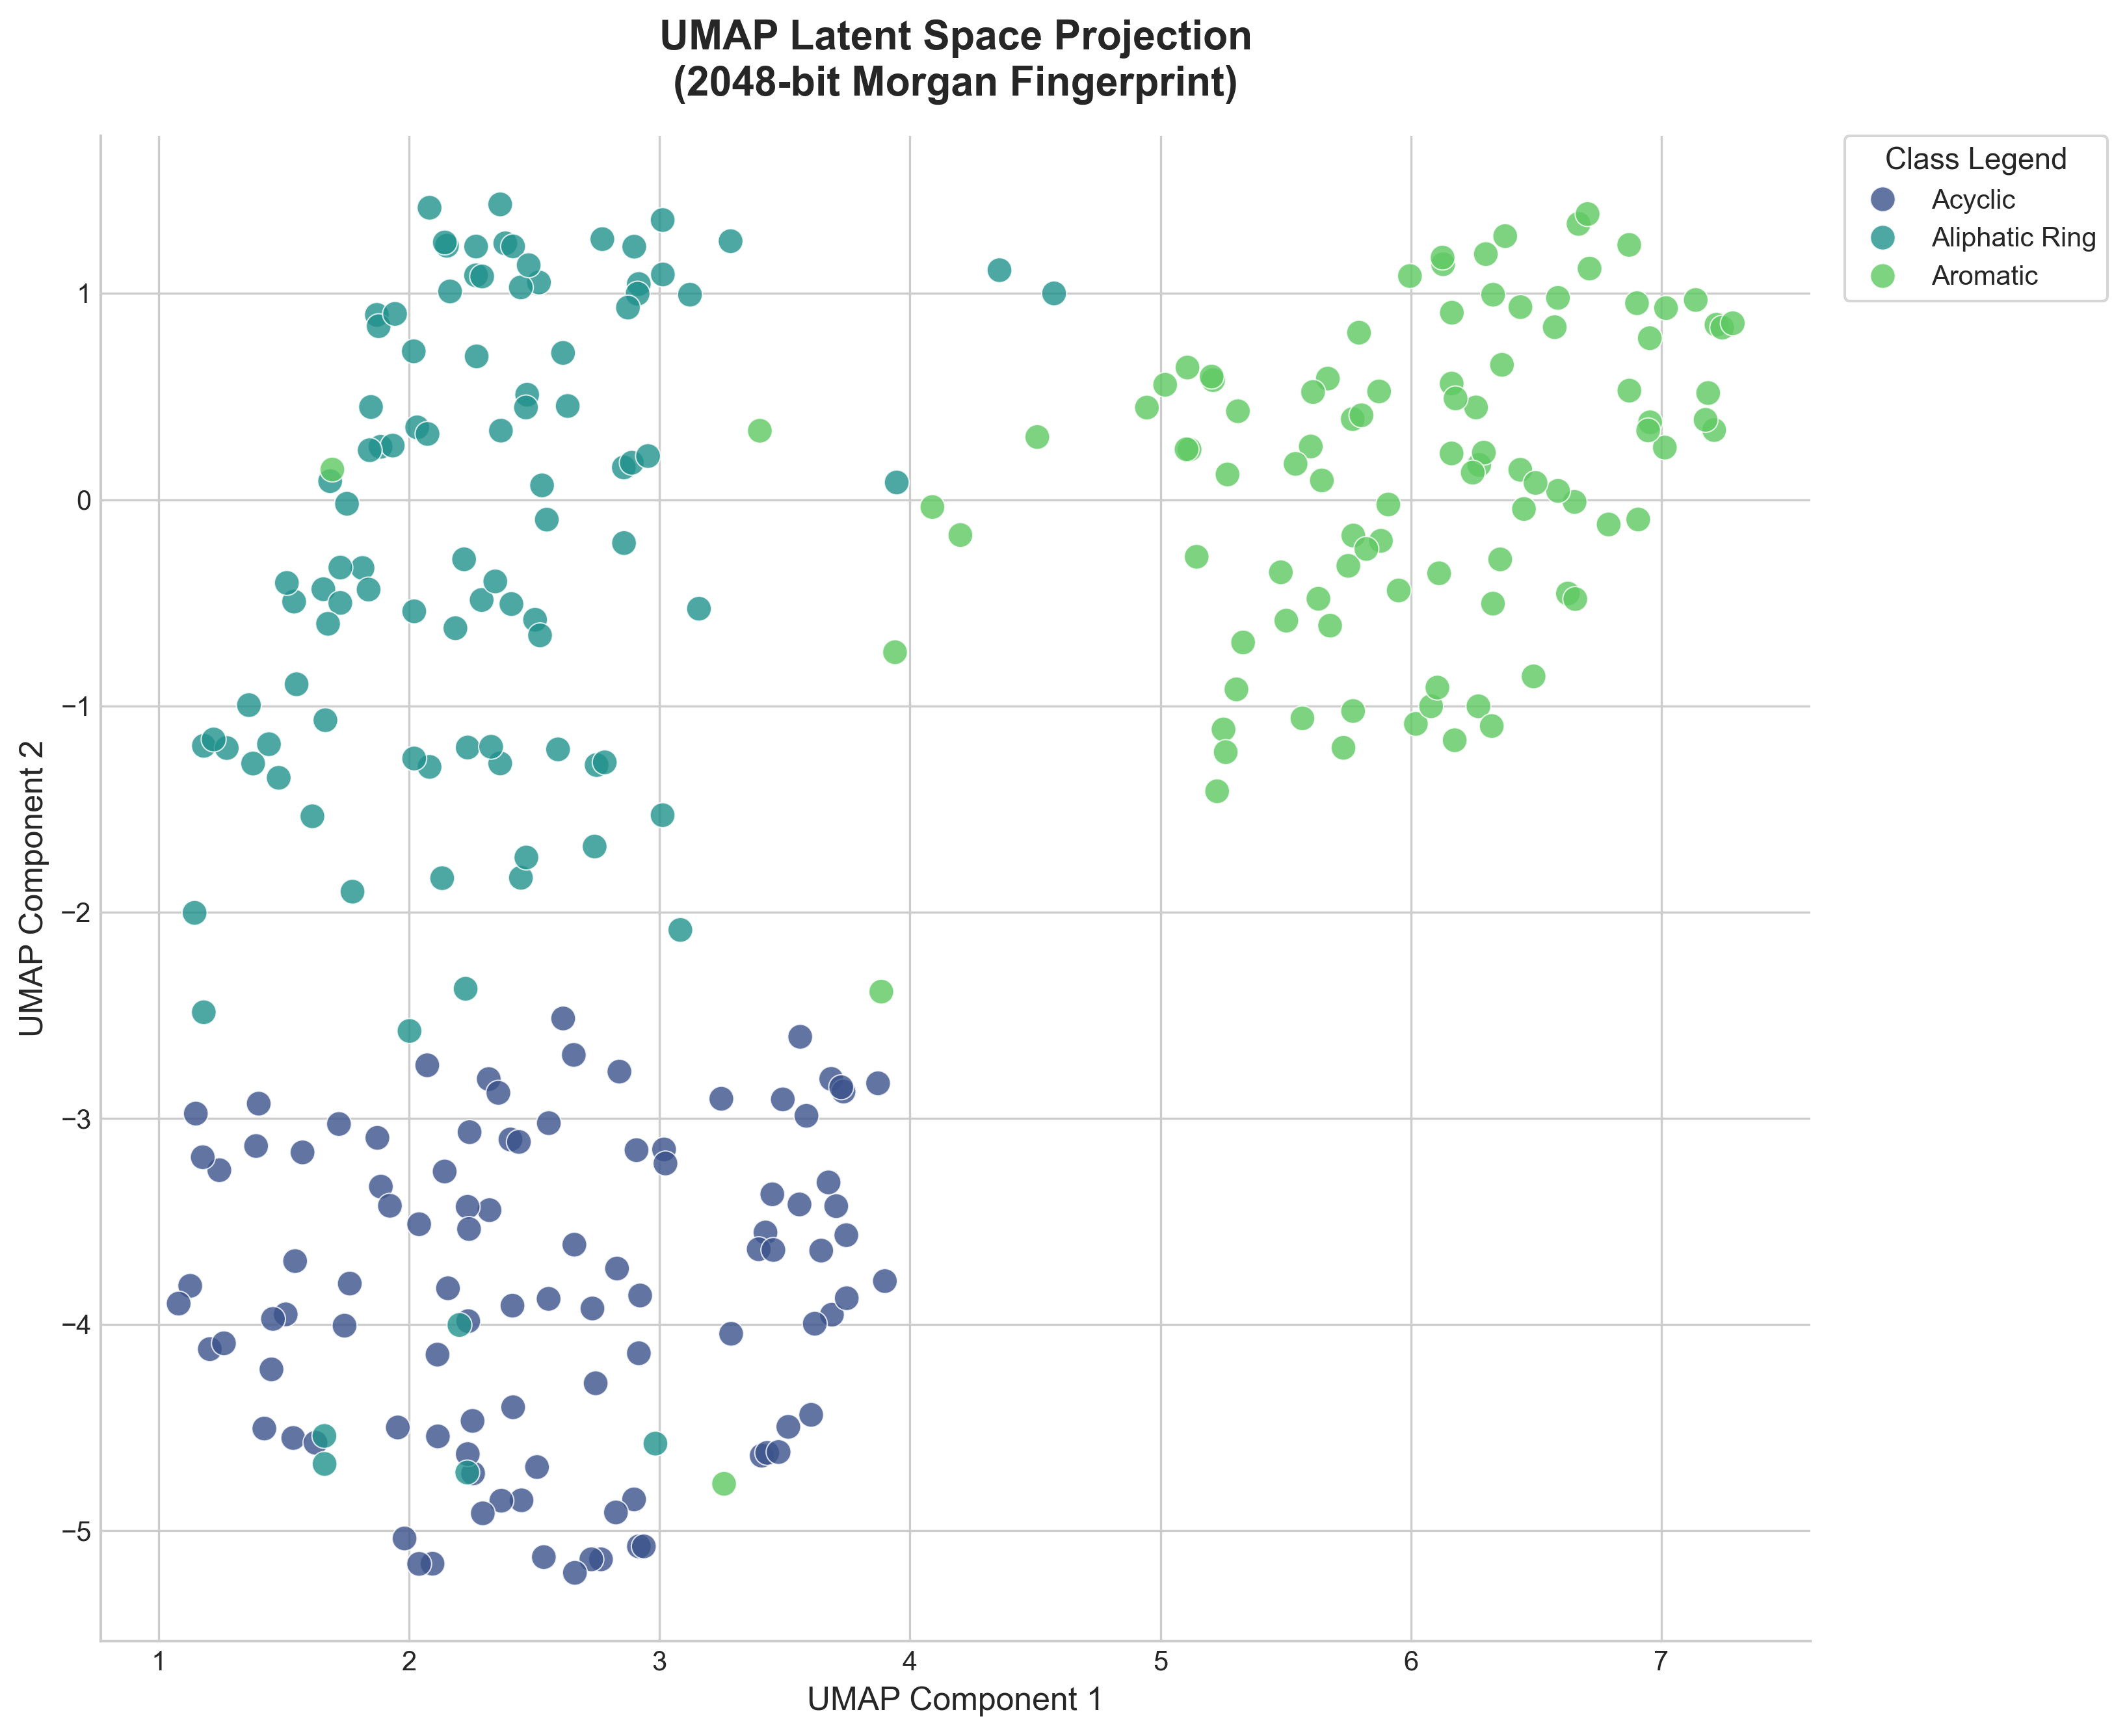

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Computing UMAP manifold reduction using 'jaccard' metric...


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved high-resolution plot to 2048_bit_morgan_fingerprint_umap.png


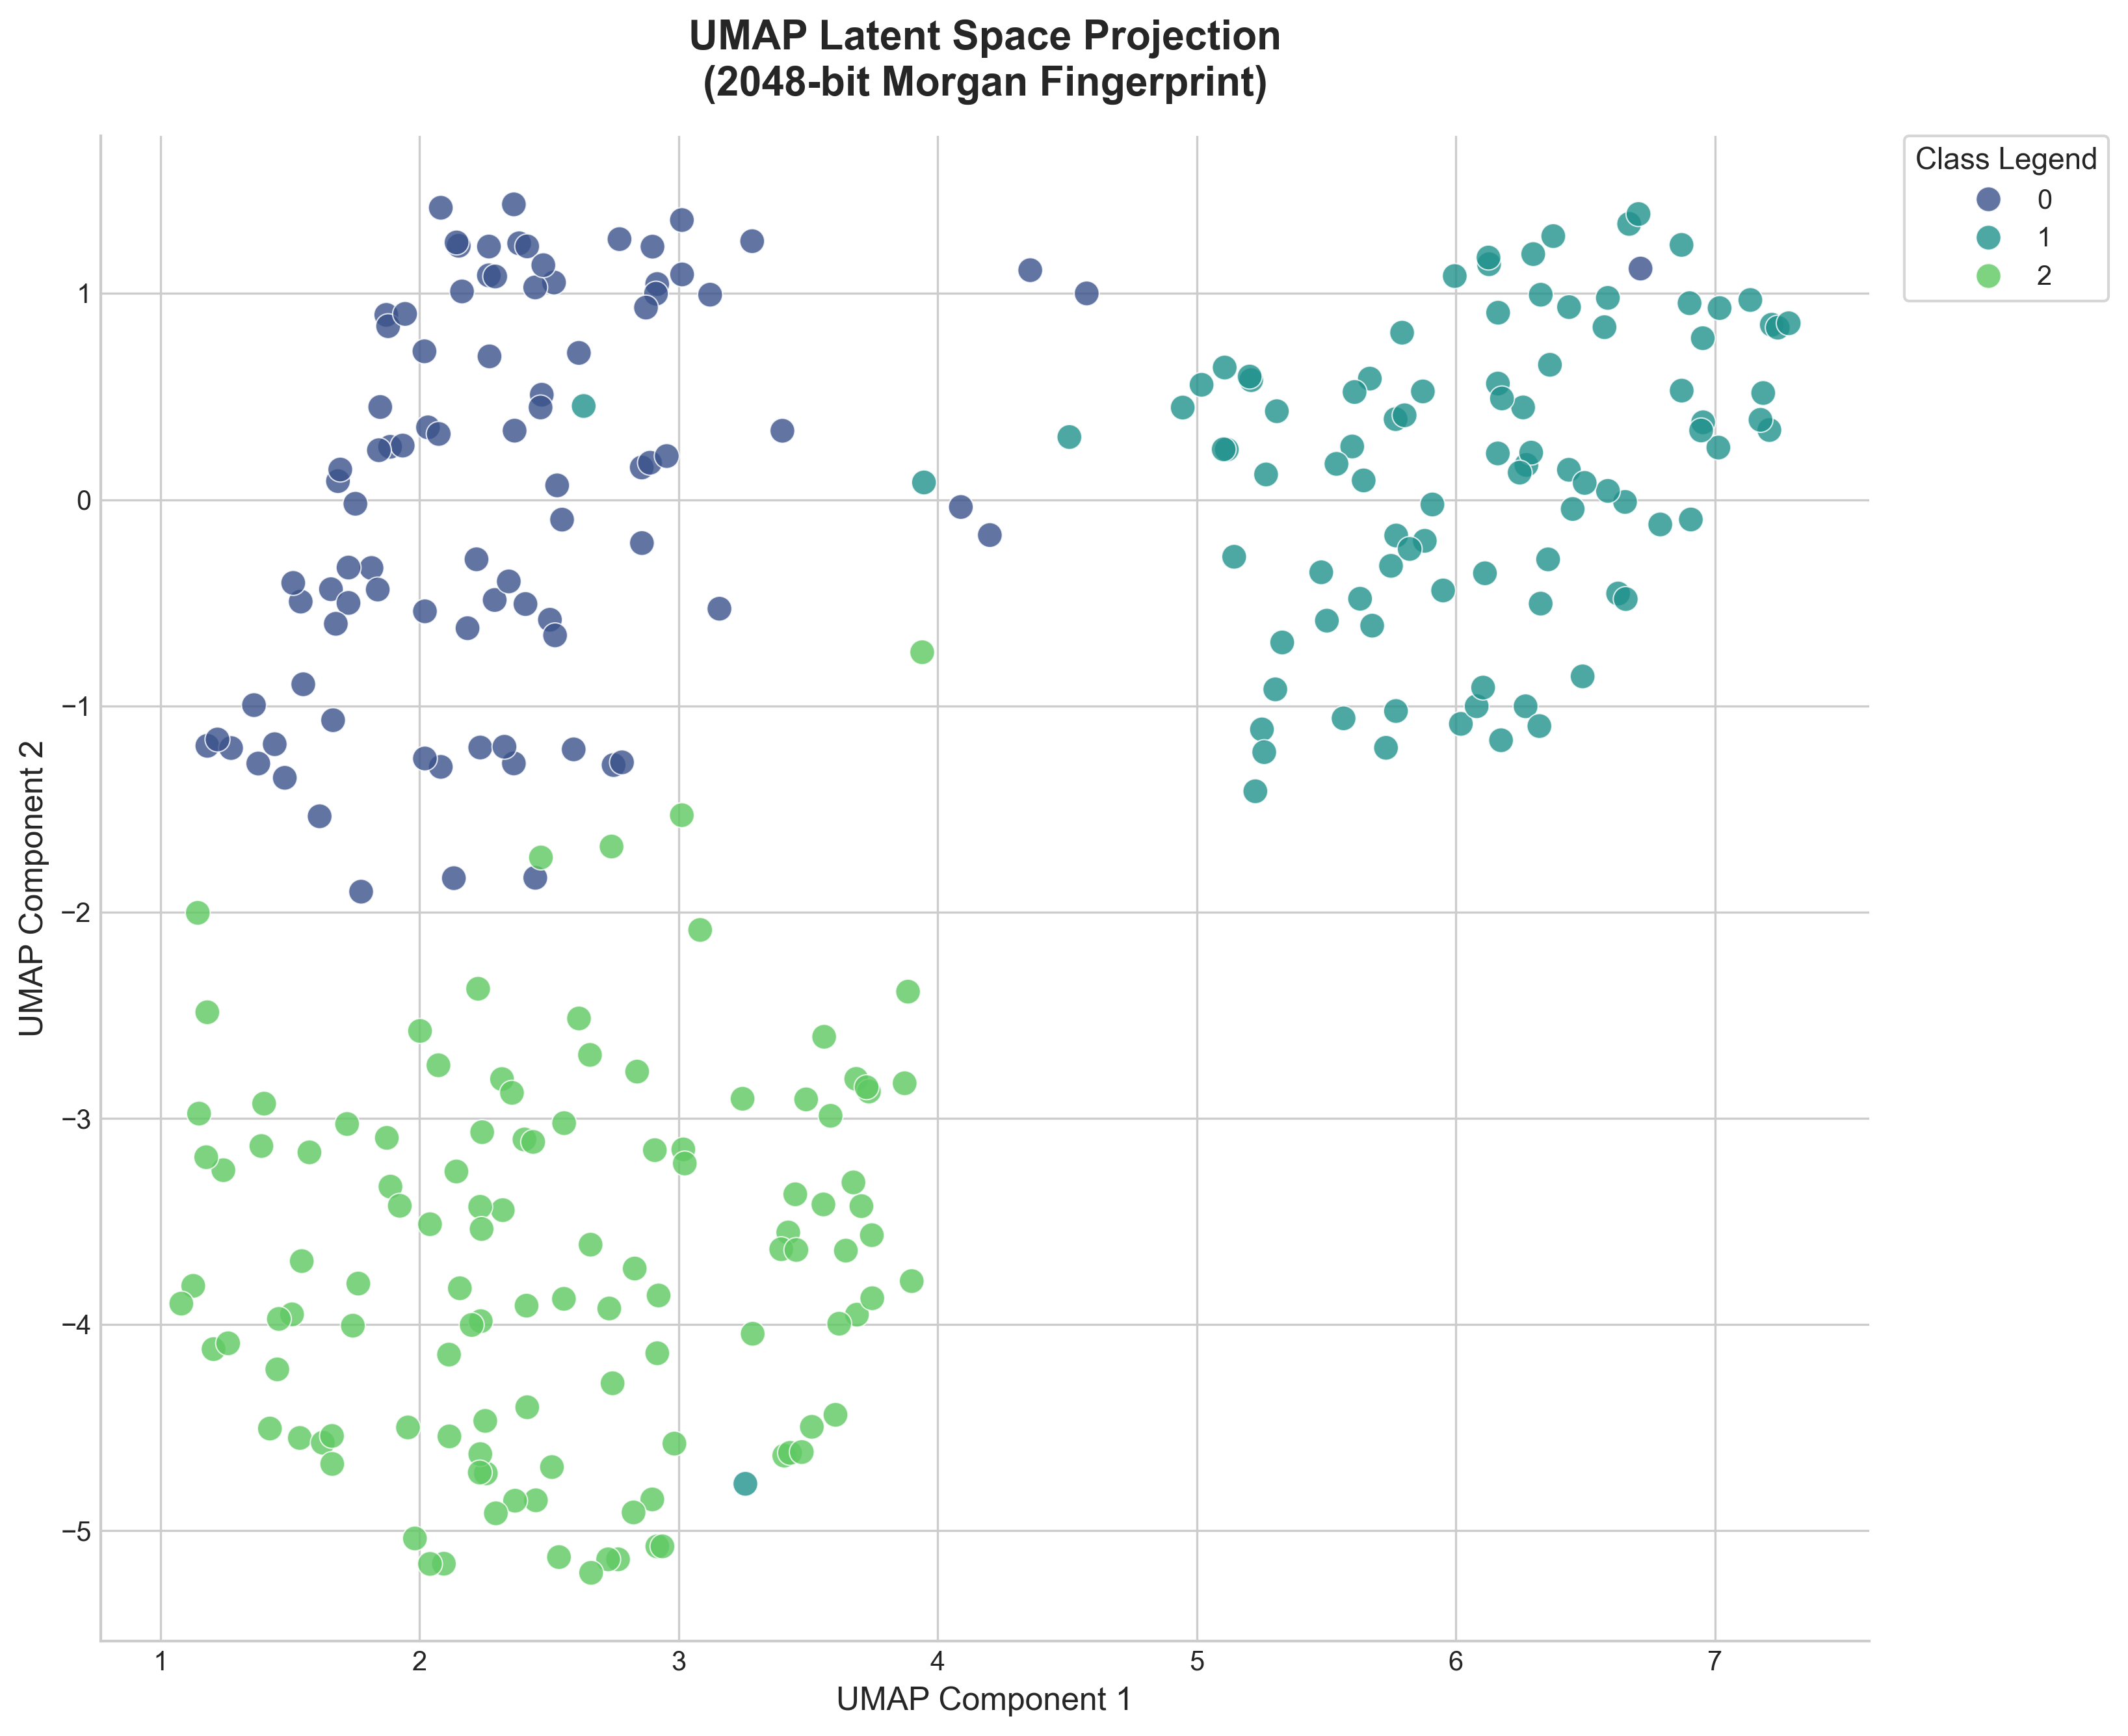

In [8]:
# NOTE: "PLOTS"
# # Extract the raw feature vector block
X_morgan = np.vstack(df_exp["morgan_fingerprint"].to_numpy())
X_chemprop = np.vstack(df_exp["chemprop_embedding"].to_numpy())

# # USE CASE A: Plot with Ground Truth Chemical Class Labels
_=plot_embedding_projection(
    X=X_morgan, 
    labels=true_labels, 
    embedding_type="morgan"
)

umap = UMAP(n_neighbors=5, metric='jaccard', random_state=42)
X_morgan_umap = umap.fit_transform(X_morgan)
labels = predict_hierarchical_clusters(X_morgan_umap, 3, "chemprop")

_=plot_embedding_projection(
     X=X_morgan, 
     labels=labels, 
     embedding_type="morgan_fingerprint"
)

# Functional Groups

In [6]:
qm9_all = QM9Dataset(limit=None)
df_all = qm9_all.load()
df_all = df_all.filter((~pl.col("functional_groups").str.contains(',')) & (pl.col("functional_groups") != ""))

2026-06-11 09:45:38.523 | INFO     | src.datasets:_load_full_qm9_df:934 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-06-11 09:45:39.014 | INFO     | src.datasets:_sample_qm9_df:1118 - QM9 sampling complete: strategy=stratified, requested_limit=None, returned_rows=124232, sampling on columns=['num_atoms', 'gap'].


In [7]:
df_cleaned = (
    df_all
    .filter(
        pl.col("functional_groups").is_in(["ether", "alcohol", "amine"]),
        pl.col("num_rings") == 0,
        pl.col("num_heteroatoms") <= 2
    )
)

# 2. Optimize strictly for raw_token_count (The critical OHE confounder)
best_config = (
    df_cleaned
    .group_by("raw_token_count", "functional_groups")
    .len()
    # Find the bottleneck group size for each token_count
    .group_by("raw_token_count")
    .agg(
        pl.col("functional_groups").n_unique().alias("unique_group_count"),
        pl.col("len").min().alias("min_samples_per_group")
    )
    # Enforce that all 3 functional groups must exist at this token length
    .filter(pl.col("unique_group_count") == 3)
    # Maximize our balanced sample pool
    .sort("min_samples_per_group", descending=True)
    .head(1)
)

token_counts_df = (
    df_cleaned
    .group_by("raw_token_count", "functional_groups")
    .len()
    .group_by("raw_token_count")
    .agg(
        pl.col("functional_groups").n_unique().alias("unique_group_count"),
        pl.col("len").min().alias("min_samples_per_group")
    )
    .filter(pl.col("unique_group_count") == 3)
    .sort("min_samples_per_group", descending=True)
)

best_config = token_counts_df.head(1)
optimal_token_count = best_config["raw_token_count"].item(0)
max_equal_n = best_config["min_samples_per_group"].item(0)

df_sample = (
    df_cleaned
    .filter(pl.col("raw_token_count") == optimal_token_count)
    .group_by("functional_groups")
    .map_groups(lambda group: group.sample(n=30, seed=42, with_replacement=False))
    .sort("functional_groups")
)

In [15]:
import polars as pl
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from scripts.qm9.chemprop import CheMeleonFingerprint
from rdkit import Chem
from rdkit.Chem import AllChem
import selfies as sf
from umap import UMAP
from sklearn.metrics import pairwise_distances, silhouette_score, adjusted_rand_score
from sklearn.cluster import AgglomerativeClustering

# --- 1. Representation Generation Functions ---

def compute_semantic_embeddings(selfies_series: pl.Series, layer_idx: int = 6) -> np.ndarray:
    device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
    model_name = "HUBioDataLab/SELFormer"
    
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    model = AutoModel.from_pretrained(model_name, trust_remote_code=True, output_hidden_states=True).to(device)
    model.eval()
    
    clean_selfies = [s.replace("][", "] [") if s else "[nop]" for s in selfies_series.to_list()]
    embeddings = []
    
    with torch.no_grad():
        for s in clean_selfies:
            inputs = tokenizer(s, return_tensors="pt").to(device)
            outputs = model(**inputs)
            hidden_states = outputs.hidden_states[layer_idx]
            mean_pooled = torch.mean(hidden_states, dim=1)
            embeddings.append(mean_pooled.squeeze().cpu().numpy())
            
    return np.array(embeddings)


def compute_morgan_fingerprint(smile: str, radius: int, n_bits: int = 2048) -> np.ndarray:
    mol = Chem.MolFromSmiles(smile)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    return np.array(fp, dtype=np.int8)


def compute_selfies_onehot(selfies_series: pl.Series) -> np.ndarray:
    """Transforms a series of SELFIES into flattened, padded one-hot vectors."""
    selfies_list = selfies_series.to_list()
    
    # Extract alphabet and determine maximum sequence length for padding
    alphabet = sf.get_alphabet_from_selfies(selfies_list)
    alphabet.add("[nop]")  # Ensure padding token is in the alphabet
    vocab_to_idx = {token: idx for idx, token in enumerate(sorted(list(alphabet)))}
    
    max_len = max(sf.len_selfies(s) for s in selfies_list)
    onehot_vectors = []
    
    for s in selfies_list:
        # Convert string to integer tokens, padding with [nop] up to max_len
        encoding = sf.selfies_to_encoding(
            selfies=s, 
            vocab_stoi=vocab_to_idx, 
            pad_to_len=max_len, 
            enc_type="one_hot"
        )
        # Flatten the (max_len, vocab_size) matrix into a 1D vector
        onehot_vectors.append(np.array(encoding).flatten())
        
    return np.array(onehot_vectors, dtype=np.int8)

In [16]:

X_embeddings = compute_semantic_embeddings(df_sample["selfies"], layer_idx=6)

chemeleon = CheMeleonFingerprint()
fps = chemeleon(df_sample["smiles"].to_list())

morgan_fps = [compute_morgan_fingerprint(s, radius=2) for s in df_sample["smiles"].to_list()]

onehot_fps = compute_selfies_onehot(df_sample["selfies"])

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

2026-06-11 09:50:00.921 | INFO     | scripts.qm9.chemprop:__init__:28 - Initializing CheMeleonFingerprint generator...
2026-06-11 09:50:00.923 | INFO     | scripts.qm9.chemprop:__init__:48 - Found existing CheMeleon weights at /Users/karlfindhansen/.chemprop/chemeleon_mp.pt
2026-06-11 09:50:00.990 | SUCCESS  | scripts.qm9.chemprop:__init__:54 - Successfully loaded CheMeleon message passing weights.
2026-06-11 09:50:01.002 | INFO     | scripts.qm9.chemprop:__call__:75 - Generating CheMeleon fingerprints for 90 molecules...
2026-06-11 09:50:01.804 | SUCCESS  | scripts.qm9.chemprop:__call__:100 - Successfully generated 90 fingerprints of dimension 2048.


In [17]:

true_labels = df_sample["functional_groups"].to_numpy()
n_classes = len(np.unique(true_labels))

# Map matrices into evaluation catalog
representation_catalog = {
    "selfies_semantic_layer6": np.vstack(X_embeddings),
    "chemeleon_foundation_embedding": np.vstack(fps),
    "morgan_fingerprint_r2": np.vstack(morgan_fps),
    "selfies_onehot": np.vstack(onehot_fps)
}

results = []

for name, X in representation_catalog.items():
    
    # Assign automated metrics and linkages based on data profile
    # Both Morgan fingerprints and One-Hot strings are sparse binary markers
    if "morgan" in name or "onehot" in name:
        X = X.astype(bool)
        raw_metric = "jaccard"
        umap_metric = "jaccard"
        
        # Binary configuration using precomputed Jaccard distances
        hc_raw = AgglomerativeClustering(n_clusters=n_classes, metric='precomputed', linkage='complete')
        dist_matrix = pairwise_distances(X, metric=raw_metric)
        raw_preds = hc_raw.fit_predict(dist_matrix)
        sil_raw = silhouette_score(dist_matrix, raw_preds, metric='precomputed')
    else:
        raw_metric = "euclidean"
        umap_metric = "euclidean"
        
        # Dense continuous vector configuration
        hc_raw = AgglomerativeClustering(n_clusters=n_classes, metric='euclidean', linkage='ward')
        raw_preds = hc_raw.fit_predict(X)
        sil_raw = silhouette_score(X, raw_preds, metric='euclidean')
        
    ari_raw = adjusted_rand_score(true_labels, raw_preds)
    
    # Generate the 2D Topological Manifold Projection
    reducer = UMAP(n_components=2, metric=umap_metric, n_neighbors=15, min_dist=0.1, random_state=42)
    X_umap = reducer.fit_transform(X)
    
    # Partition on the Manifest Manifold Coordinates
    hc_umap = AgglomerativeClustering(n_clusters=n_classes, metric='euclidean', linkage='ward')
    umap_preds = hc_umap.fit_predict(X_umap)
    
    sil_umap = silhouette_score(X_umap, umap_preds, metric='euclidean')
    ari_umap = adjusted_rand_score(true_labels, umap_preds)
    
    results.append({
        "Embedding Type": name,
        "Raw Silhouette": round(sil_raw, 4),
        "Raw ARI": round(ari_raw, 4),
        "UMAP Silhouette": round(sil_umap, 4),
        "UMAP ARI": round(ari_umap, 4)
    })

# Compile Overview
df_results = pl.DataFrame(results)
print("\n=== CLUSTERING PERFORMANCE BENCHMARK ===")
print(df_results)

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/


=== CLUSTERING PERFORMANCE BENCHMARK ===
shape: (4, 5)
┌────────────────────────────────┬────────────────┬─────────┬─────────────────┬──────────┐
│ Embedding Type                 ┆ Raw Silhouette ┆ Raw ARI ┆ UMAP Silhouette ┆ UMAP ARI │
│ ---                            ┆ ---            ┆ ---     ┆ ---             ┆ ---      │
│ str                            ┆ f64            ┆ f64     ┆ f64             ┆ f64      │
╞════════════════════════════════╪════════════════╪═════════╪═════════════════╪══════════╡
│ selfies_semantic_layer6        ┆ 0.2872         ┆ 0.0629  ┆ 0.6637          ┆ 0.0536   │
│ chemeleon_foundation_embedding ┆ 0.1519         ┆ 0.2457  ┆ 0.4618          ┆ 0.4951   │
│ morgan_fingerprint_r2          ┆ 0.0937         ┆ 0.4463  ┆ 0.6252          ┆ 0.1257   │
│ selfies_onehot                 ┆ 0.0972         ┆ 0.035   ┆ 0.4834          ┆ 0.0199   │
└────────────────────────────────┴────────────────┴─────────┴─────────────────┴──────────┘
